# Assignment 13: Generative AI Essentials

**Student Name:** Mohammad Tamim Hamkar

## Step 1: Introduction to Generative AI

Generative AI is a type of artificial intelligence that can create new content such as text, images, music, and code. It learns patterns from existing data and uses those patterns to generate new content.

In this assignment, I will train a simple text generation model using a text dataset. After training the model, I will give it some starting text and see how it can generate new text based on what it learned.


## Step 2: Dataset Preparation

For this assignment, I selected *Alice's Adventures in Wonderland* by Lewis Carroll from Project Gutenberg. It is a publicly available text that can be used to train a simple text generation model.

In this step, I load the text and check the size and a small sample of the dataset.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Download the text dataset from Project Gutenberg
import tensorflow as tf

file_path = tf.keras.utils.get_file(
    "alice.txt",
    "https://www.gutenberg.org/files/11/11-0.txt"
)

# Read the text file
text = open(file_path, "rb").read().decode("utf-8")

# Display basic information about the dataset
print("Total characters:", len(text))
print("\nSample text:")
print(text[:500])

151191/151191 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total characters: 144696

Sample text:
*** START OF THE PROJECT GUTENBERG EBOOK 11 ***

[Illustration]




Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

 CHAPTER I.     Down the Rabbit-Hole
 CHAPTER II.    The Pool of Tears
 CHAPTER III.   A Caucus-Race and a Long Tale
 CHAPTER IV.    The Rabbit Sends in a Little Bill
 CHAPTER V.     Advice from a Caterpillar
 CHAPTER VI.    Pig and Pepper
 CHAPTER VII.   A Mad Tea-Party
 CHAPTER VIII.  The Queen’s Croquet-Ground
 CHAPTER IX.    The


## Step 3: Prepare the Text for Training

Here, I prepare the text for the model by identifying the unique characters and converting each character into a number that the neural network can understand.

In [3]:
# Find all unique characters in the text
vocab = sorted(set(text))

# Create mappings between characters and numbers
char_to_index = {char: index for index, char in enumerate(vocab)}
index_to_char = np.array(vocab)

# Convert the text into numbers
text_as_int = np.array([char_to_index[char] for char in text])

print("Number of unique characters:", len(vocab))
print("First 100 characters:")
print(text[:100])
print("\nFirst 100 encoded values:")
print(text_as_int[:100])

Number of unique characters: 76
First 100 characters:
*** START OF THE PROJECT GUTENBERG EBOOK 11 ***

[Illustration]




Alice’s Adventures in Wonderland

First 100 encoded values:
[ 5  5  5  1 33 34 15 32 34  1 29 20  1 34 22 19  1 30 32 29 24 19 17 34
  1 21 35 34 19 28 16 19 32 21  1 19 16 29 29 25  1 10 10  1  5  5  5  0
  0 41 23 55 55 64 62 63 61 44 63 52 58 57 42  0  0  0  0  0 15 55 52 46
 48 73 62  1 15 47 65 48 57 63 64 61 48 62  1 52 57  1 37 58 57 47 48 61
 55 44 57 47]


## Step 4: Create Training Sequences

Here, I divide the text into smaller sequences. These sequences will help the model learn the patterns in the text and predict what character should come next.

In [4]:
# Set the length of each text sequence
sequence_length = 100

# Create sequences from the encoded text
sequences = []

for i in range(0, len(text_as_int) - sequence_length):
    sequences.append(text_as_int[i:i + sequence_length + 1])

sequences = np.array(sequences)

# Separate each sequence into input and target
X = sequences[:, :-1]
y = sequences[:, 1:]

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (144596, 100)
Target shape: (144596, 100)


## Step 5: Build the Text Generation Model

Here, I build a simple neural network for text generation. The model uses an Embedding layer and LSTM layers to learn patterns and relationships between characters in the text.

In [5]:
# Build the text generation model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(sequence_length,)),
    tf.keras.layers.Embedding(len(vocab), 128),
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.Dense(len(vocab))
])

# Display the model structure
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │         9,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100, 76)        │         9,804 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,700 (1.08 MB)

 Trainable params: 282,700 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Compile the Model

Here, I compile the text generation model using the Adam optimizer and sparse categorical crossentropy loss. This prepares the model for training.

In [6]:
# Compile the model
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## Step 7: Train the Text Generation Model

Here, I train the model using the prepared text sequences. During training, the model learns patterns from the text and improves its ability to predict the next character.

In [7]:
# Train the text generation model
history = model.fit(
    X,
    y,
    epochs=5,
    batch_size=64,
    validation_split=0.10
)

Epoch 1/5
2034/2034 ━━━━━━━━━━━━━━━━━━━━ 1036s 508ms/step - accuracy: 0.4719 - loss: 1.8742 - val_accuracy: 0.5406 - val_loss: 1.5920
Epoch 2/5
2034/2034 ━━━━━━━━━━━━━━━━━━━━ 1023s 503ms/step - accuracy: 0.6160 - loss: 1.2901 - val_accuracy: 0.5691 - val_loss: 1.5006
Epoch 3/5
2034/2034 ━━━━━━━━━━━━━━━━━━━━ 1022s 502ms/step - accuracy: 0.6792 - loss: 1.0650 - val_accuracy: 0.5676 - val_loss: 1.5612
Epoch 4/5
2034/2034 ━━━━━━━━━━━━━━━━━━━━ 1042s 502ms/step - accuracy: 0.7310 - loss: 0.8936 - val_accuracy: 0.5568 - val_loss: 1.7018
Epoch 5/5
2034/2034 ━━━━━━━━━━━━━━━━━━━━ 1035s 499ms/step - accuracy: 0.7749 - loss: 0.7548 - val_accuracy: 0.5456 - val_loss: 1.8915


## Step 8: Visualize the Training Results

Here, I visualize the training and validation accuracy and loss. This helps me understand how the model learned during training and whether it performed well on unseen data.

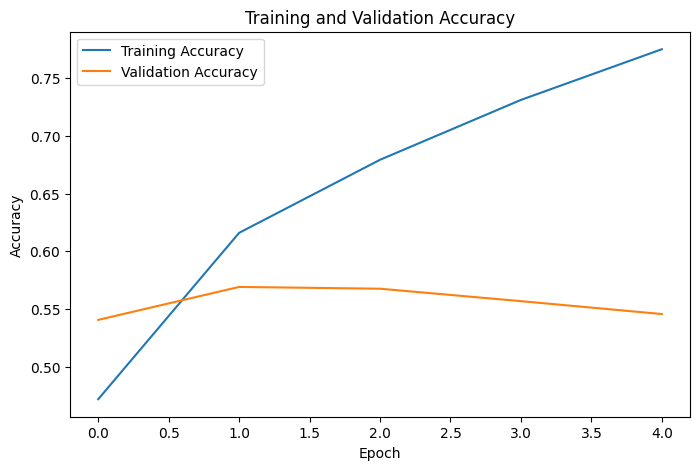

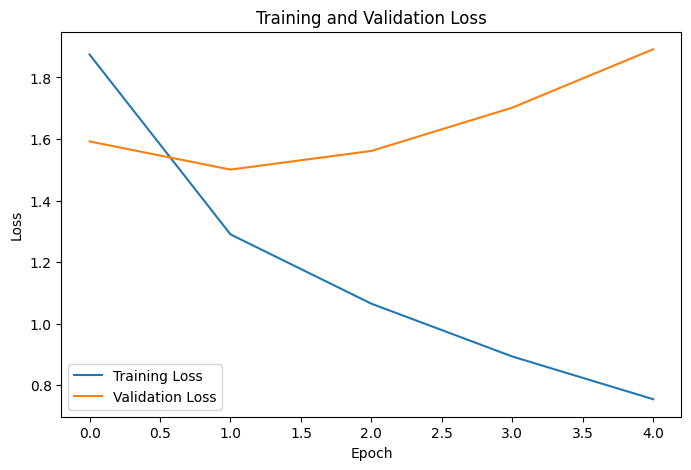

In [9]:
# Plot training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

## Step 9: Generate New Text

Here, I test the trained model by giving it some starting text, called seed text. The model then predicts one character at a time to create new text based on the patterns it learned from the book.

In [10]:
# Function to generate new text
def generate_text(model, seed_text, num_generate=300, temperature=0.8):
    generated_text = seed_text

    for _ in range(num_generate):
        # Keep the most recent 100 characters
        input_text = generated_text[-sequence_length:]

        # Pad the beginning if the seed is shorter than 100 characters
        input_text = input_text.rjust(sequence_length)

        # Convert characters to numbers
        input_ids = [
            char_to_index.get(char, char_to_index[" "])
            for char in input_text
        ]

        input_ids = np.array([input_ids])

        # Predict the next character
        predictions = model.predict(input_ids, verbose=0)
        predictions = predictions[0, -1, :] / temperature

        # Select the next character
        predicted_id = tf.random.categorical(
            predictions[None, :], num_samples=1
        )[0, 0].numpy()

        next_char = index_to_char[predicted_id]
        generated_text += next_char

    return generated_text


# Give the model some starting text
seed_text = "Alice was"

generated_text = generate_text(
    model,
    seed_text,
    num_generate=300
)

print("Generated Text:\n")
print(generated_text)

Generated Text:

Alice was a little
sendering on.

“Who are you’d before,” she said, “and then a little
bust be
grinning of them sort of things her hand.
The first. This time there party stand _his_ child, for me one fell after her as well
along
for itself off them,
and befoming English,
and the Lory wop to his fict!” its ch


## Step 10: Findings

The model was able to generate new text after being trained on *Alice's Adventures in Wonderland*. Some parts of the generated text looked like real English sentences, while other parts contained incorrect or unusual words.

The training accuracy reached 77.49%, while the validation accuracy was 54.56%. The graphs also showed that the model started to overfit because the training performance continued to improve while the validation performance became worse.

Overall, this experiment showed me how a simple Generative AI model can learn patterns from text and use those patterns to create new content. It also showed that a small model trained on a limited dataset will not always generate clear or accurate text.

## Step 11: Understanding GPT Architecture

GPT stands for Generative Pre-trained Transformer. It is an AI model that can understand and generate text based on what it has learned from large amounts of written information.

GPT uses something called a Transformer. An important part of this is the attention mechanism, which helps the model understand which words or parts of a sentence are important and how they connect with each other.

Before GPT can understand text, it breaks the text into smaller pieces called tokens. It then looks at the previous tokens and predicts what is most likely to come next. It continues predicting one token at a time to create sentences and longer responses.

GPT is pre-trained on a large amount of text, which helps it learn language patterns and how words are commonly used together. This is what allows it to generate text that can sound natural and meaningful.

## Step 12: Ethical Considerations

Generative AI can be very useful, but it also comes with some concerns. For example, AI can sometimes create incorrect information, repeat bias from its training data, or generate content that looks real even when it is not.

I think it is important to use Generative AI responsibly. Information created by AI should be checked before using or sharing it. We should also be careful about privacy, copyright, and fairness. Human judgment is still important because AI should support people, not replace responsible decision-making.

## Step 13: Practical Application

A simple real-world use of this model could be creative writing. A user can enter a few starting words, and the model can continue the text by generating new content based on what it learned during training.

In my example, I used “Alice was” as the starting text. The model continued the sentence and created its own text. The result was not always perfect, but it showed how Generative AI can be used to help create ideas for stories or other written content.

## Step 14: Conclusion

In this assignment, I learned how Generative AI can create new text by learning patterns from existing data. I trained a simple text generation model using *Alice's Adventures in Wonderland* and tested it with seed text.

The model was able to generate new content, although some of the results were not always clear or accurate. I also learned how GPT models use transformers, attention, and tokens to generate text. Overall, this assignment helped me better understand how text generation works, as well as the benefits and ethical concerns of Generative AI.